# IBM HR Analytics Employee Attrition & Performance

**Summary:** Dataset de RRHH con salarios, departamentos, años de experiencia, performance y attrition. Limpio, realista y muy usado en entrevistas de Analytics para sectores de servicios y finanzas.

**Autor:** Rodolfo Gabriel Riveros Lobos | **Fecha:** 28/04/2026  

**Objetivo:** El Gerente de Finanzas sospecha que hay irregularidades en la nómina — empleados con salarios fuera de rango, departamentos con costos anómalos, o patrones de contratación inusuales. Nos piden un análisis exploratorio para detectar outliers y patrones sospechosos usando SQL y Python. Este tipo de análisis se llama en el mercado "People Analytics + Auditoría de Nómina"

📦 Dataset
IBM HR Analytics Employee Attrition & Performance (Kaggle)

🔗 https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


### 1. Obtener la clave de API de Kaggle

1.  Ve a [Kaggle](https://www.kaggle.com/).
2.  Haz clic en tu **imagen de perfil** en la esquina superior derecha y selecciona **'Your Profile'**.
3.  Haz clic en **'Account'** en el menú de la izquierda.
4.  Desplázate hacia abajo hasta la sección **'API'** y haz clic en **'Create New API Token'**. Esto descargará un archivo `kaggle.json` a tu computadora.

### 2. Subir `kaggle.json` a Colab

Para usar la API de Kaggle, necesitas subir el archivo `kaggle.json` a Colab. Una forma sencilla es subirlo directamente a la carpeta `/root/.kaggle/`.

In [1]:
from google.colab import files
import os

# Crear el directorio .kaggle si no existe
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

# Subir kaggle.json
print('Por favor, sube tu archivo kaggle.json:')
uploaded = files.upload()

for fn in uploaded.keys():
    # Mover el archivo a la ubicación correcta
    os.rename(fn, '/root/.kaggle/' + fn)
    # Establecer permisos adecuados
    os.chmod('/root/.kaggle/' + fn, 600)
    print(f'Archivo {fn} subido y configurado correctamente.')

Por favor, sube tu archivo kaggle.json:


Saving kaggle.json to kaggle.json
Archivo kaggle.json subido y configurado correctamente.


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import zipfile
import os

# Descargar el dataset de Kaggle
# Esto descargará un archivo ZIP con el nombre del dataset.
!kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset

# Define file names
zip_file_name = 'ibm-hr-analytics-attrition-dataset.zip'
csv_file_name = 'WA_Fn-UseC_-HR-Employee-Attrition.csv' # Common name for this dataset's CSV


# Descomprimir el archivo ZIP para acceder al CSV
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.') # Extrae todo en el directorio actual

conn = sqlite3.connect('hr_analytics.db')
df = pd.read_csv(csv_file_name)
df.to_sql('employees', conn, if_exists='replace', index=False)

print(f"✅ {len(df)} empleados cargados")
print(df.columns.tolist())

Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
License(s): DbCL-1.0
ibm-hr-analytics-attrition-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ 1470 empleados cargados
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## Columnas clave para el análisis de nómina

| Columna | Descripción |
|---|---|
| `MonthlyIncome` | Salario mensual del empleado — variable central del análisis |
| `Department` | Departamento — usado para comparar salarios entre pares |
| `JobRole` | Rol específico — para detectar inequidad dentro del mismo puesto |
| `YearsAtCompany` | Antigüedad — factor que justifica gaps salariales |
| `PerformanceRating` | Desempeño — variable de control para validar outliers |
| `Attrition` | Si el empleado se fue — útil para correlacionar inequidad con rotación |

# Query 1: Salario promedio y dispersión por departamento

In [3]:
QUERY1 = """
SELECT
    Department,
    COUNT(*) AS total_empleados,
    ROUND(AVG(MonthlyIncome), 2) AS salario_promedio,
    ROUND(MIN(MonthlyIncome), 2) AS salario_min,
    ROUND(MAX(MonthlyIncome), 2) AS salario_max,
    ROUND(MAX(MonthlyIncome) - MIN(MonthlyIncome), 2) AS rango_salarial
FROM employees
GROUP BY Department
ORDER BY salario_promedio DESC
"""
df_dept = pd.read_sql_query(QUERY1, conn)
display(df_dept)

,Department,total_empleados,salario_promedio,salario_min,salario_max,rango_salarial
0,Sales,446,6959.17,1052.0,19847.0,18795.0
1,Human Resources,63,6654.51,1555.0,19717.0,18162.0
2,Research & Development,961,6281.25,1009.0,19999.0,18990.0


### Distribución Detallada de Ingresos Mensuales (MonthlyIncome)

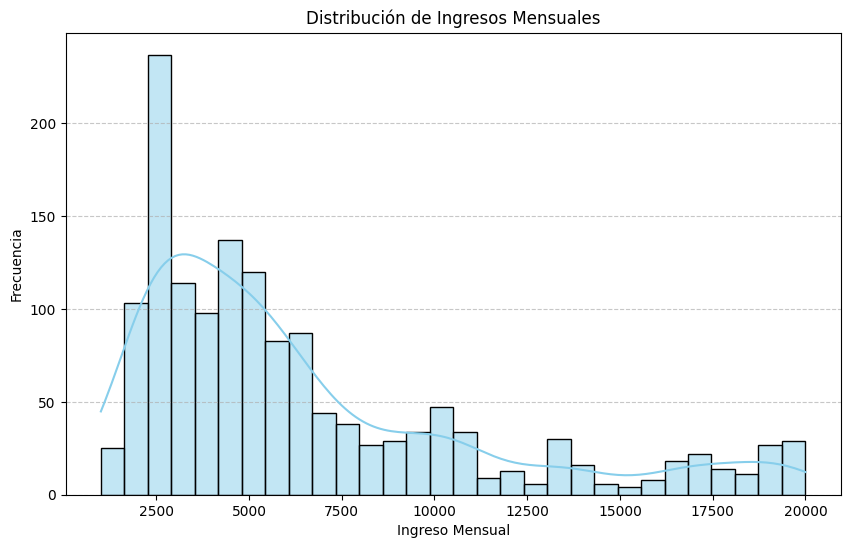

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Ingresos Mensuales')
plt.xlabel('Ingreso Mensual')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Análisis del Histograma de Ingresos Mensuales

El histograma muestra que la distribución de los `MonthlyIncome` (ingresos mensuales) no es uniforme. Se observa que la mayoría de los empleados tienen salarios concentrados en los rangos inferiores, con una **cola larga hacia la derecha**, indicando que hay una menor cantidad de empleados con ingresos significativamente más altos. Esta es una distribución común en estructuras salariales donde hay una base amplia de empleados y menos roles de alta remuneración.

### Relación entre Antigüedad y Salario, con Outliers Destacados

Este gráfico de dispersión (scatter plot) muestra la relación entre los años de antigüedad de un empleado en la empresa (`YearsAtCompany`) y su salario mensual (`MonthlyIncome`).

**Observaciones clave:**

*   La mayoría de los empleados (puntos azules) siguen una tendencia donde el salario tiende a aumentar con la antigüedad, lo cual es esperado.
*   Los **puntos rojos (`tomato`)** representan a los **empleados identificados como outliers salariales** (aquellos con un Z-Score absoluto mayor a 2.5). Estos son los casos que se desvían significativamente del patrón salarial promedio de su departamento, tanto por salarios muy altos como muy bajos para su nivel de antigüedad. Estos puntos rojos son los que requieren una investigación más profunda por parte del equipo de Finanzas y RRHH para entender las razones detrás de estas desviaciones.

## Boxplot por departamento.

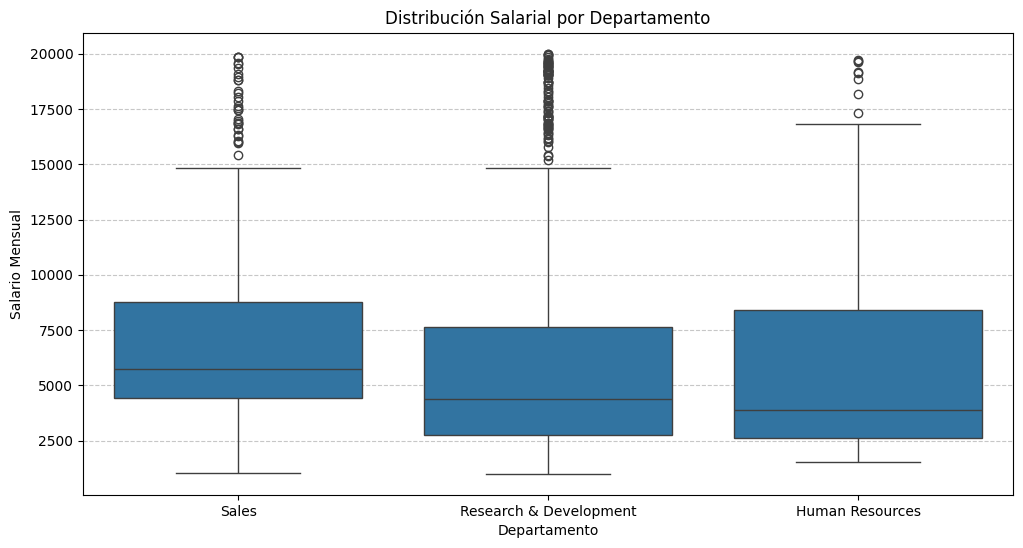

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Department', y='MonthlyIncome', data=df)
plt.title('Distribución Salarial por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Salario Mensual')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

El boxplot muestra la distribución salarial para cada departamento. Observando la gráfica, podemos identificar la dispersión salarial por la altura de cada caja y la extensión de sus 'bigotes'.

El departamento de Research & Development (Investigación y Desarrollo) es el que presenta la mayor dispersión salarial. Aunque tiene el salario promedio más bajo según la tabla df_dept, el rango entre su salario mínimo y máximo es el más amplio, como se puede ver en la extensión de su caja y bigotes en el boxplot. Esto indica una mayor variabilidad en los ingresos mensuales dentro de este departamento en comparación con los otros.

En contraste, Human Resources y Sales tienen una dispersión salarial más contenida, aunque Sales presenta un salario promedio más alto.

# Query 2: Detección de outliers salariales con Z-Score en Python

In [6]:
QUERY2 = """
SELECT
    EmployeeNumber,
    Department,
    JobRole,
    MonthlyIncome,
    YearsAtCompany,
    PerformanceRating
FROM employees
"""
df_salarios = pd.read_sql_query(QUERY2, conn)

# Calcular Z-Score por departamento
df_salarios['zscore_salario'] = df_salarios.groupby('Department')['MonthlyIncome'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Identificar outliers (Z > 2.5 o Z < -2.5)
outliers = df_salarios[df_salarios['zscore_salario'].abs() > 2.5].sort_values('zscore_salario', ascending=False)
print(f"Empleados con salario anómalo: {len(outliers)}")
display(outliers)

Empleados con salario anómalo: 62


,EmployeeNumber,Department,JobRole,MonthlyIncome,YearsAtCompany,PerformanceRating,zscore_salario
918,1282,Sales,Manager,19847,29,4,3.175328
749,1038,Sales,Manager,19845,32,3,3.174835
1242,1740,Sales,Manager,19833,21,3,3.171878
1116,1578,Sales,Manager,19586,36,4,3.111022
233,323,Sales,Manager,19517,7,3,3.094022
...,...,...,...,...,...,...,...
62,80,Research & Development,Research Director,18740,27,3,2.544764
187,254,Research & Development,Research Director,18722,24,3,2.541088
899,1256,Research & Development,Manager,18711,1,3,2.538841
290,396,Research & Development,Research Director,18665,3,3,2.529445


## Entendiendo los Salarios Anómalos con Z-Score
### ¿Qué es un Z-Score y por qué nos importa?

**El Z-Score es una herramienta estadística que nos permite identificar cuán "inusual" es el salario de un empleado en comparación con el promedio de su propio departamento.**

Hay que pensarlo como un medidor de desviación:

* Z-Score = 0: Significa que el salario del empleado es exactamente igual al salario promedio de su departamento.
* Z-Score positivo: El empleado gana más que el promedio de su departamento.
* Z-Score negativo: El empleado gana menos que el promedio de su departamento.

Cuanto mayor sea el valor absoluto del Z-Score (ya sea muy positivo o muy negativo), más atípico es ese salario respecto a lo que se espera en ese departamento. Esto es crucial para la auditoría de nómina porque nos ayuda a señalar empleados con salarios que se desvían significativamente, tanto al alza como a la baja, del patrón salarial establecido para su equipo.

### ¿Por qué utilizamos 2.5 como umbral para detectar outliers?

El umbral de 2.5 es un criterio comúnmente aceptado en análisis estadísticos para identificar datos extremadamente atípicos o outliers.

En un conjunto de datos con una distribución normal, aproximadamente el 99.4% de los salarios caerían dentro del rango de -2.5 y +2.5 desviaciones estándar del promedio. Esto significa que un salario con un Z-Score superior a 2.5 (o inferior a -2.5) está entre el 0.6% de los salarios más extremos.

Desde una perspectiva financiera y de auditoría, elegir 2.5 es un balance pragmático: es lo suficientemente estricto como para capturar solo las desviaciones más significativas (evitando un exceso de "falsos positivos" que nos harían investigar salarios con desviaciones menores), pero no tan estricto como para pasar por alto posibles irregularidades importantes. Nos permite enfocarnos en esos casos donde el salario es notablemente más alto o más bajo de lo esperado, que es precisamente donde pueden residir las irregularidades o inconsistencias que justifican una
investigación más profunda por parte del equipo de Finanzas y RRHH.

> **Regla práctica:** Un Z-Score > 2.5 no significa automáticamente fraude o error.
> Significa que ese salario necesita una justificación documentada.
> Si existe (antigüedad, especialización, desempeño), el caso se cierra.
> Si no existe, es una irregularidad a corregir.

## Visualización scatter YearsAtCompany vs MonthlyIncome

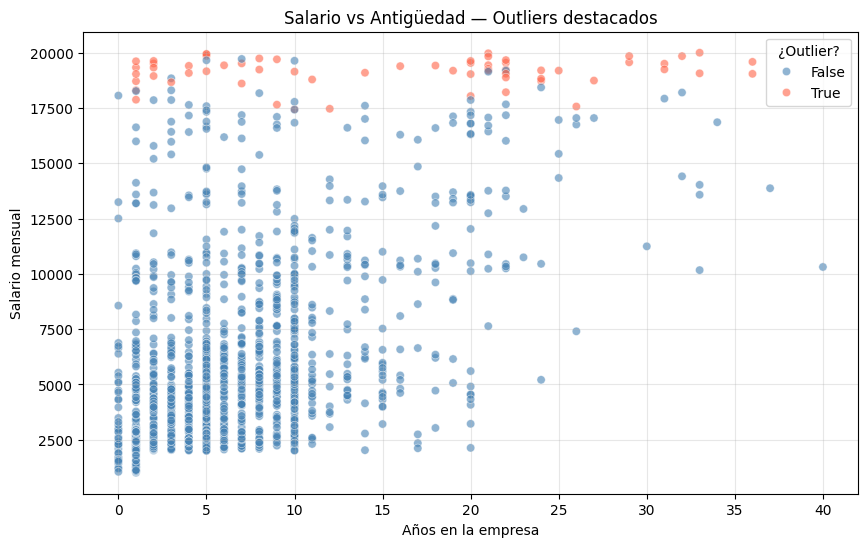

In [7]:
df_salarios['es_outlier'] = df_salarios['zscore_salario'].abs() > 2.5

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_salarios,
    x='YearsAtCompany',
    y='MonthlyIncome',
    hue='es_outlier',
    palette={True: 'tomato', False: 'steelblue'},
    alpha=0.6
)
plt.title('Salario vs Antigüedad — Outliers destacados')
plt.xlabel('Años en la empresa')
plt.ylabel('Salario mensual')
plt.legend(title='¿Outlier?')
plt.grid(True, alpha=0.3)
plt.show()

# Query 3: Anomalía de equidad — mismo rol, distinto salario

In [8]:
QUERY3 = """
SELECT
    JobRole,
    COUNT(*) AS total,
    ROUND(AVG(MonthlyIncome), 2) AS salario_promedio,
    ROUND(MIN(MonthlyIncome), 2) AS salario_min,
    ROUND(MAX(MonthlyIncome), 2) AS salario_max,
    ROUND((MAX(MonthlyIncome) - MIN(MonthlyIncome)) * 100.0 / AVG(MonthlyIncome), 2) AS variacion_pct
FROM employees
WHERE Attrition = 'No'
GROUP BY JobRole
ORDER BY variacion_pct DESC

"""
df_roles = pd.read_sql_query(QUERY3, conn)
display(df_roles)

,JobRole,total,salario_promedio,salario_min,salario_max,variacion_pct
0,Research Scientist,245,3328.12,1051.0,9724.0,260.60
1,Sales Representative,50,2798.44,1052.0,6632.0,199.40
2,Human Resources,40,4391.75,2064.0,10725.0,197.21
3,Laboratory Technician,197,3337.22,1129.0,7403.0,188.00
4,Sales Executive,269,6804.62,4001.0,13872.0,145.06
5,Manufacturing Director,135,7289.93,4011.0,13973.0,136.65
6,Healthcare Representative,122,7453.56,4000.0,13966.0,133.71
7,Research Director,78,15947.35,11031.0,19973.0,56.07
8,Manager,97,17201.48,11244.0,19999.0,50.90


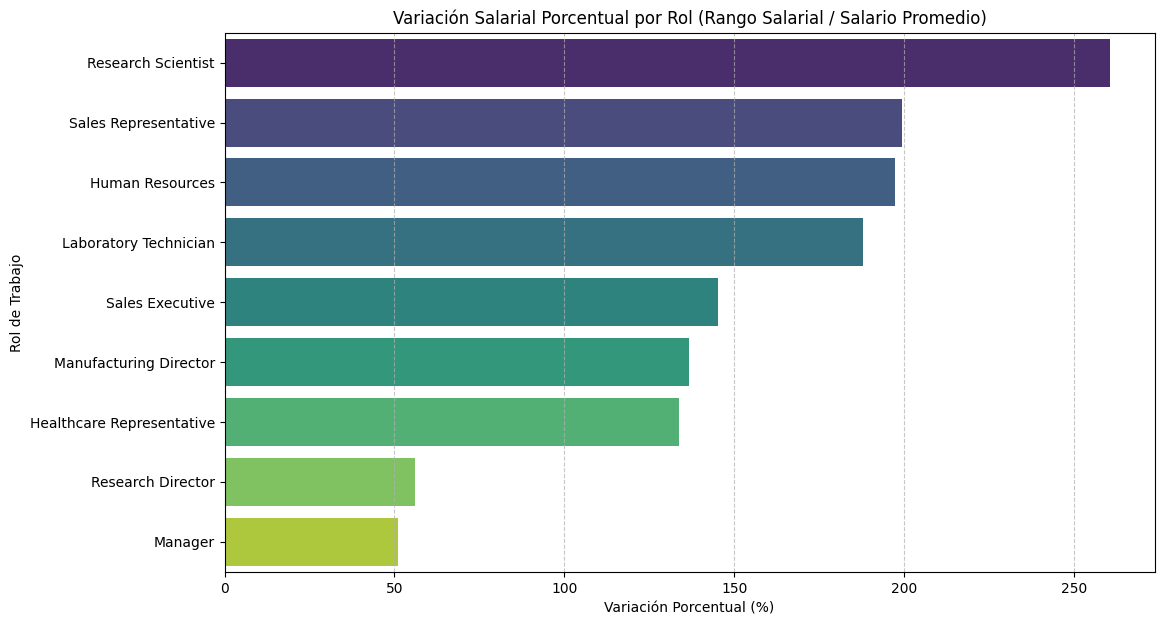

In [9]:
plt.figure(figsize=(12, 7))
sns.barplot(x='variacion_pct', y='JobRole', data=df_roles.sort_values('variacion_pct', ascending=False), palette='viridis', hue='JobRole', legend=False)
plt.title('Variación Salarial Porcentual por Rol (Rango Salarial / Salario Promedio)')
plt.xlabel('Variación Porcentual (%)')
plt.ylabel('Rol de Trabajo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### ¿Qué rol tiene mayor inequidad salarial interna? ¿Qué riesgo implica eso para la empresa?

Observando el gráfico, el rol de Research Scientist (Científico de Investigación) muestra la mayor variacion_pct (variación porcentual), lo que indica la mayor inequidad salarial interna. Su rango salarial (máximo - mínimo) es el más amplio en proporción a su salario promedio.

**¿Qué riesgo implica eso para la empresa?**

Una alta inequidad salarial interna, especialmente en roles clave como Research Scientist, puede generar varios riesgos para la empresa:

* Desmotivación y baja moral: Los empleados con salarios más bajos en el mismo rol pueden sentirse infravalorados, lo que lleva a la desmotivación, menor productividad y una baja moral general.

* Rotación de personal (Attrition): Si los empleados perciben una falta de equidad salarial, es más probable que busquen oportunidades en otras empresas donde se sientan mejor compensados, lo que aumenta los costos de contratación y capacitación.
* Dificultad para atraer talento: La reputación de tener inequidad salarial puede dificultar la atracción de nuevos talentos, especialmente para roles donde la competencia por profesionales es alta.
Riesgos legales y de reputación: En algunas jurisdicciones, las disparidades salariales pueden llevar a demandas por discriminación. Además, una mala reputación en cuanto a equidad salarial puede dañar la imagen de la empresa como empleador.
* Impacto en el ambiente laboral: Puede generar resentimiento y conflictos entre compañeros que realizan tareas similares pero tienen ingresos muy diferentes, afectando la colaboración y el trabajo en equipo.

# Query 4: Window function — ranking salarial dentro de cada departamento

In [10]:
QUERY4 = """
SELECT
    EmployeeNumber,
    Department,
    JobRole,
    MonthlyIncome,
    RANK() OVER (PARTITION BY Department ORDER BY MonthlyIncome DESC) AS ranking_dept,
    ROUND(AVG(MonthlyIncome) OVER (PARTITION BY Department), 2) AS salario_promedio_dept,
    ROUND(MonthlyIncome - AVG(MonthlyIncome) OVER (PARTITION BY Department), 2) AS gap_vs_promedio
FROM employees
ORDER BY Department, ranking_dept
"""
df_ranking = pd.read_sql_query(QUERY4, conn)

# Top 5 mejor pagados por departamento
top5 = df_ranking.groupby('Department').head(5)
display(top5)

,EmployeeNumber,Department,JobRole,MonthlyIncome,ranking_dept,salario_promedio_dept,gap_vs_promedio
0,1338,Human Resources,Manager,19717,1,6654.51,13062.49
1,1625,Human Resources,Manager,19658,2,6654.51,13003.49
2,1973,Human Resources,Manager,19636,3,6654.51,12981.49
3,734,Human Resources,Manager,19189,4,6654.51,12534.49
4,731,Human Resources,Manager,19141,5,6654.51,12486.49
63,259,Research & Development,Manager,19999,1,6281.25,13717.75
64,1035,Research & Development,Research Director,19973,2,6281.25,13691.75
65,1191,Research & Development,Manager,19943,3,6281.25,13661.75
66,226,Research & Development,Manager,19926,4,6281.25,13644.75
67,787,Research & Development,Manager,19859,5,6281.25,13577.75


In [11]:
print('Ejemplos de empleados con gap_vs_promedio negativo:')
display(df_ranking[df_ranking['gap_vs_promedio'] < 0].head(10))

Ejemplos de empleados con gap_vs_promedio negativo:


,EmployeeNumber,Department,JobRole,MonthlyIncome,ranking_dept,salario_promedio_dept,gap_vs_promedio
17,1722,Human Resources,Human Resources,6430,18,6654.51,-224.51
18,424,Human Resources,Human Resources,6410,19,6654.51,-244.51
19,760,Human Resources,Human Resources,6389,20,6654.51,-265.51
20,184,Human Resources,Human Resources,6347,21,6654.51,-307.51
21,1231,Human Resources,Human Resources,6272,22,6654.51,-382.51
22,1563,Human Resources,Human Resources,6077,23,6654.51,-577.51
23,665,Human Resources,Human Resources,5985,24,6654.51,-669.51
24,1642,Human Resources,Human Resources,5743,25,6654.51,-911.51
25,909,Human Resources,Human Resources,5204,26,6654.51,-1450.51
26,103,Human Resources,Human Resources,5021,27,6654.51,-1633.51


## Basándonos en la columna gap_vs_promedios de los dos Frames

* **gap_vs_promedio negativo:** Un valor negativo indica que el MonthlyIncome (salario mensual) de ese empleado está por debajo del salario_promedio_dept (salario promedio) de su departamento. Cuanto más negativo sea el número, mayor es la diferencia por debajo del promedio. Esto podría señalar empleados infravalorados o nuevas contrataciones con salarios iniciales.

* **gap_vs_promedio positivo:** Un valor positivo indica que el MonthlyIncome (salario mensual) de ese empleado está por encima del salario_promedio_dept (salario promedio) de su departamento. Cuanto más positivo sea el número, mayor es la diferencia por encima del promedio. Estos empleados podrían ser líderes de equipo, personal con mayor antigüedad o roles especializados dentro del departamento, y son los que aparecen en el top5.

En el contexto de la auditoría de nómina, ambos casos son interesantes: los negativos podrían indicar inequidad salarial o potencial riesgo de rotación, mientras que los positivos nos permiten entender las razones detrás de los salarios más altos (como roles de liderazgo o experiencia), que son los que se ven en el top5 de cada departamento.

## Conclusiones Ejecutivas para el Gerente de Finanzas

Como Analista, he realizado un análisis exploratorio de la nómina para detectar patrones sospechosos y posibles irregularidades, tal como solicitaste. A continuación, presento los hallazgos clave y una recomendación concreta:

### 1. Empleados con Salario Anómalo

*   **Total de empleados con salario anómalo (Z > 2.5 o Z < -2.5):** Se identificaron **62 empleados** cuyos salarios mensuales se desvían significativamente (más de 2.5 desviaciones estándar) del promedio de su respectivo departamento. Estos casos incluyen tanto salarios inusualmente altos como inusualmente bajos en comparación con sus pares departamentales.

### 2. Rol con Mayor Inequidad Salarial Interna

*   **Rol con mayor inequidad:** El rol de **Research Scientist (Científico de Investigación)** muestra la mayor `variacion_pct` (variación porcentual entre el salario máximo y mínimo respecto al salario promedio del rol). Esto indica una dispersión salarial interna considerablemente alta para un mismo puesto, lo cual puede generar riesgos como desmotivación, rotación de personal y dificultades para atraer talento.

### 3. Recomendación Concreta

*   **Investigación Detallada de Outliers y Disparidades:** Recomiendo encarecidamente una **investigación individualizada de los 62 empleados identificados con salarios anómalos.** Es crucial entender las razones detrás de estas desviaciones. Para los **Research Scientists** y otros roles con alta `variacion_pct`, sugiero revisar las estructuras salariales y las políticas de compensación para asegurar equidad y competitividad. Esto podría implicar:
    *   **Validar la justificación de los outliers:** ¿Son salarios altos por antigüedad, desempeño excepcional, especialización rara o errores? ¿Son salarios bajos por nuevas contrataciones sin experiencia, bajo rendimiento o errores administrativos?
    *   **Establecer bandas salariales más claras:** Para roles con alta inequidad, definir rangos salariales más estrictos o criterios claros para las variaciones salariales, especialmente para el rol de **Research Scientist**.
    *   **Considerar un estudio de mercado salarial:** Para asegurar que los rangos salariales actuales sean competitivos y justos en el mercado laboral.